In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df = pd.read_excel('/Users/tanishkamhatre/Downloads/Housing.csv (1).xlsx')

In [37]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [38]:
df.shape

(545, 13)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [40]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [41]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [42]:
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [43]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


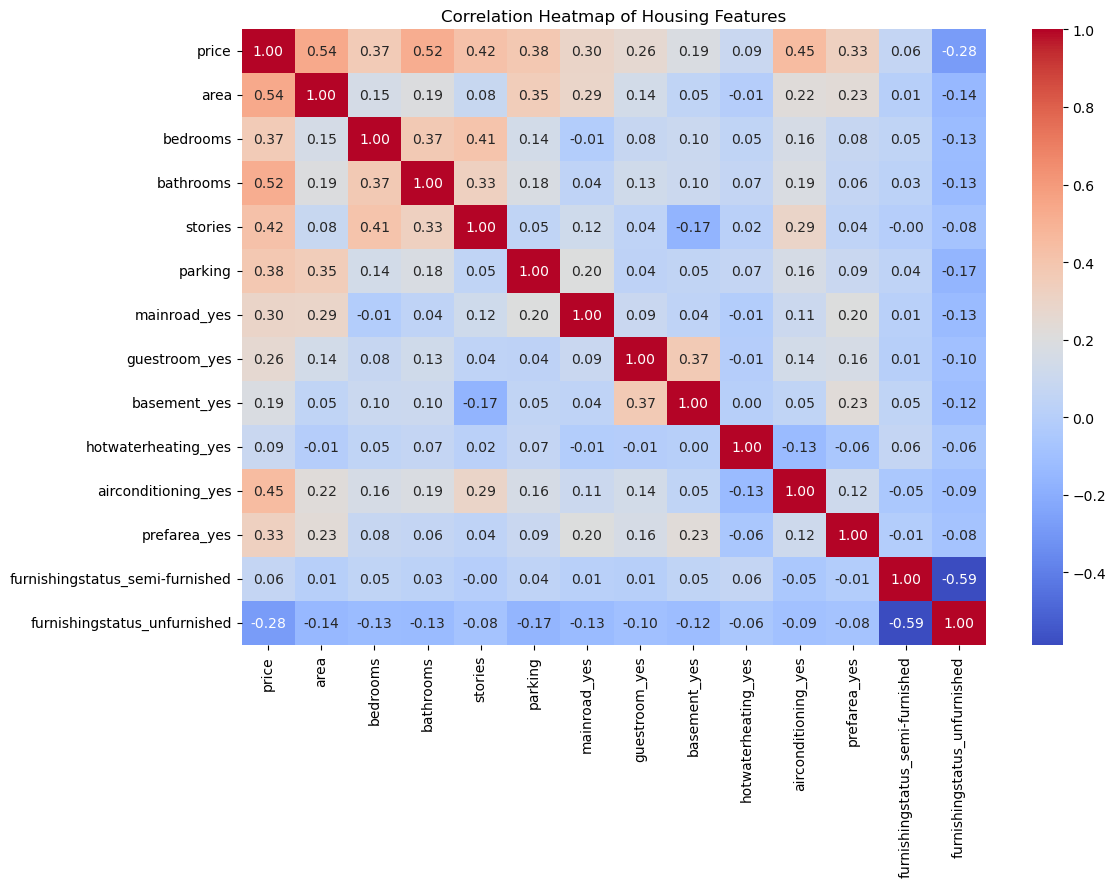

In [44]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_encoded.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Housing Features")
plt.show()

Area (0.54) and bathrooms (0.52) have the strongest positive correlations with price. Unfurnished status has a negative correlation (-0.28), while other features show weaker relationships.

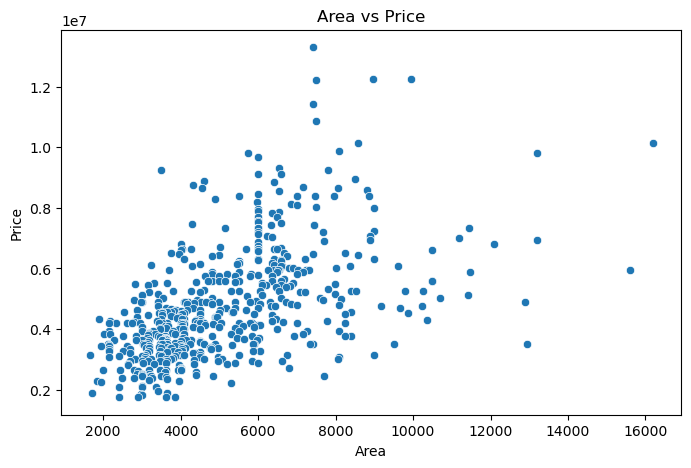

In [45]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x='area', y='price')

plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')

plt.show()

There is a positive relationship between area and price, meaning larger properties generally have higher prices. However, the spread in prices increases for larger properties, showing that other factors also affect price.

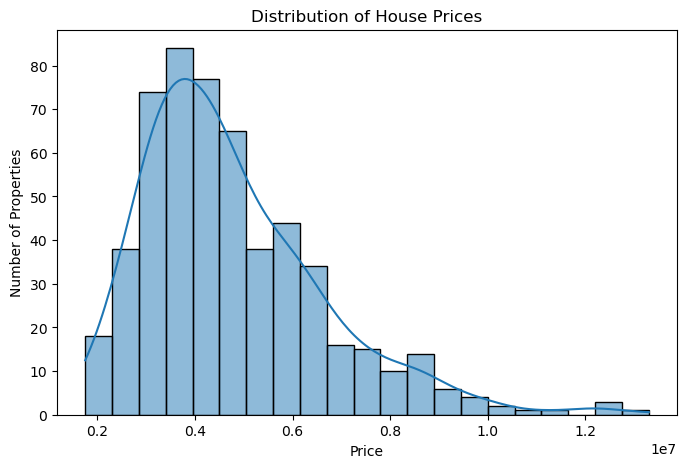

In [46]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='price', kde=True)

plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Properties')

plt.show()

The price distribution is right-skewed, with most properties concentrated around ₹3.5–4.5 million. Higher-priced properties are less common.

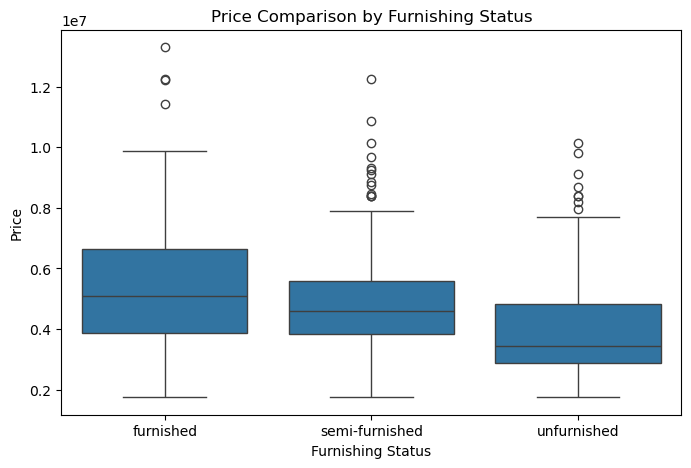

In [47]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='furnishingstatus', y='price')

plt.title('Price Comparison by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Price')

plt.show()

Furnished properties generally have higher prices than semi-furnished and unfurnished properties. Furnished properties also show greater variation in prices.

In [48]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 1324506.9600914388
R²: 0.6529242642153184


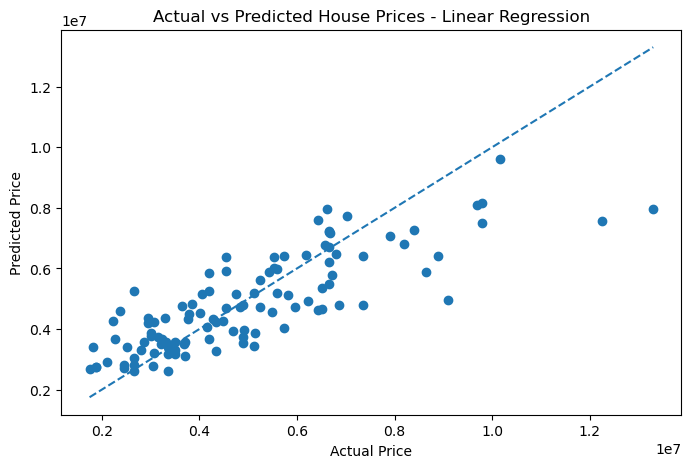

In [51]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices - Linear Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

The Linear Regression model predicts mid-range house prices reasonably well, but it tends to underestimate higher-priced properties. This indicates that the model may not fully capture the non-linear patterns in house prices.

In [52]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

In [53]:
rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [54]:
rf_pred = rf_grid.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest RMSE: 1415694.7147983578
Random Forest R²: 0.6034892329468744


In [55]:
gb = GradientBoostingRegressor(random_state=42)

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}


In [56]:
gb_pred = gb_grid.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting R²:", gb_r2)

Gradient Boosting RMSE: 1392107.657576519
Gradient Boosting R²: 0.6165917900381558


In [57]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse, rf_rmse, gb_rmse],
    'R²': [r2, rf_r2, gb_r2]
})

comparison

,Model,RMSE,R²
0,Linear Regression,1.324507e+06,0.652924
1,Random Forest,1.415695e+06,0.603489
2,Gradient Boosting,1.392108e+06,0.616592


Linear Regression achieved the lowest RMSE and highest R² on the test set among the three models. Gradient Boosting performed better than Random Forest, while Random Forest had the highest RMSE and lowest R². The results show that the tuned tree-based models did not improve the test-set performance over the baseline Linear Regression model for this dataset.

Final Report

Key Findings

1. The dataset contains 545 residential properties with features such as area, bedrooms, bathrooms, stories, parking, furnishing status, and other property characteristics.

2. No missing values were found in the dataset, so no missing-value treatment was required.

3. Area showed a relatively strong positive correlation with house price (0.54), followed by bathrooms (0.52).

4. The Area vs Price visualization showed that larger properties generally have higher prices.

5. The price distribution was right-skewed, with fewer properties in the higher price range.

6. Furnished properties generally had higher prices than semi-furnished and unfurnished properties.

7. Linear Regression achieved an RMSE of 1,324,506.96 and an R² of 0.6529.

8. Random Forest achieved an RMSE of 1,415,694.71 and an R² of 0.6035.

9. Gradient Boosting achieved an RMSE of 1,392,107.66 and an R² of 0.6166.

10. On the test set, the tuned Random Forest and Gradient Boosting models did not outperform the Linear Regression baseline.

Recommendations

- Buyers can consider property area, bathrooms, furnishing status, and other property characteristics when evaluating house prices.
- Sellers can use similar property characteristics to understand factors associated with house prices.
- Real estate analysts can use machine-learning models as supporting tools for price estimation.
- Additional relevant features and more property data could be used to improve future prediction performance.
- Model performance should be evaluated on unseen data before using a model for real-world price estimation.

Conclusion

This project demonstrated a complete Python-based data analytics and machine-learning workflow, including data cleaning, exploratory data analysis, visualization, regression modeling, hyperparameter tuning, model comparison, and business recommendations.